### IMPORTING LIBRARIES

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from skimage.feature import graycomatrix, graycoprops

### LOADING THE DATASET

In [2]:
train_path = r"C:\Users\srira\Downloads\DDSM Dataset\Train"
valid_path = r"C:\Users\srira\Downloads\DDSM Dataset\Valid"
test_path  = r"C:\Users\srira\Downloads\DDSM Dataset\Test"

IMG_SIZE   = 224
THRESHOLD  = 0.35

In [3]:
def load_dataset(path):
    images, labels = [], []
    for class_name in ['Benign', 'Malignant']:
        folder = os.path.join(path, class_name)
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            for img_path in glob(os.path.join(folder, ext)):
                images.append(img_path)
                labels.append(class_name)
    return images, labels

train_imgs, train_labels = load_dataset(train_path)
valid_imgs, valid_labels = load_dataset(valid_path)
test_imgs,  test_labels  = load_dataset(test_path)

print("Train:", len(train_imgs))
print("Valid:", len(valid_imgs))
print("Test:",  len(test_imgs))
print("Train Distribution:", Counter(train_labels))
print("Test  Distribution:", Counter(test_labels))

Train: 2100
Valid: 450
Test: 450
Train Distribution: Counter({'Malignant': 1260, 'Benign': 840})
Test  Distribution: Counter({'Malignant': 270, 'Benign': 180})


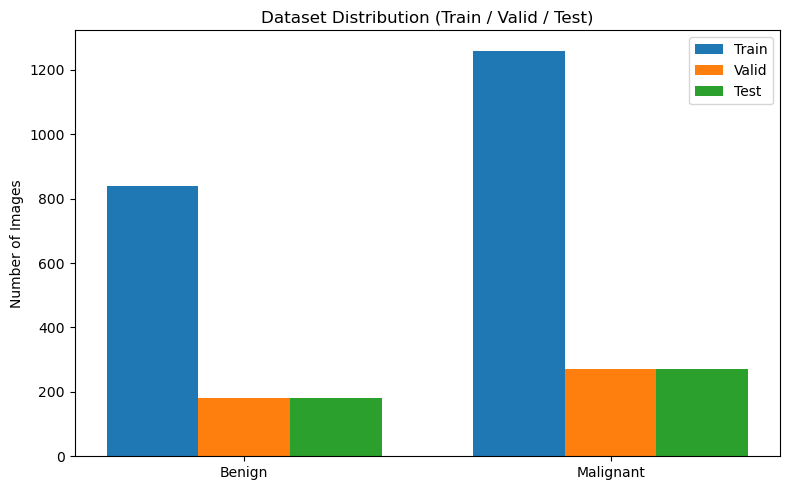

In [4]:
def plot_distribution():
    labels      = ['Benign', 'Malignant']
    train_count = Counter(train_labels)
    valid_count = Counter(valid_labels)
    test_count  = Counter(test_labels)
    x = np.arange(len(labels)); w = 0.25

    plt.figure(figsize=(8, 5))
    plt.bar(x - w, [train_count['Benign'], train_count['Malignant']], w, label='Train')
    plt.bar(x,     [valid_count['Benign'], valid_count['Malignant']], w, label='Valid')
    plt.bar(x + w, [test_count['Benign'],  test_count['Malignant']],  w, label='Test')
    plt.xticks(x, labels)
    plt.legend(); plt.title("Dataset Distribution (Train / Valid / Test)")
    plt.ylabel("Number of Images"); plt.tight_layout(); plt.show()

plot_distribution()

### DATA CLEANING AND IMAGE PRE-PROCESSING

In [5]:
def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def remove_background(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        img = img[y:y+h, x:x+w]
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE))

def denoise(img):
    img = cv2.GaussianBlur(img, (5, 5), 0)
    return cv2.medianBlur(img, 5)

def enhance(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    cl = cv2.createCLAHE(clipLimit=2.0).apply(l)
    return cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB) / 255.0

In [6]:
# U-NET SEGMENTATION  (Parameter #1 — Lesion shape/margin/orientation)
def build_unet(input_shape=(224, 224, 3)):
    inputs = tf.keras.layers.Input(input_shape)

    c1 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D()(c1)

    c2 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D()(c2)

    c3 = tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same')(p2)

    u1 = tf.keras.layers.UpSampling2D()(c3)
    u1 = tf.keras.layers.concatenate([u1, c2])
    c4 = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(u1)

    u2 = tf.keras.layers.UpSampling2D()(c4)
    u2 = tf.keras.layers.concatenate([u2, c1])
    c5 = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(u2)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(c5)
    return tf.keras.Model(inputs, outputs)

unet = build_unet()
unet.compile(optimizer='adam', loss='binary_crossentropy')

In [7]:
def get_mask(img):
    return unet.predict(np.expand_dims(img, axis=0), verbose=0)[0]

In [8]:
# PARAMETER #1 — LESION-BASED PARAMETERS
# Shape (circularity), Margin (roughness), Orientation (angle)
def extract_lesion_parameters(img_float):
    """
    Returns:
        area, perimeter, circularity (shape), margin_roughness, orientation_angle
    """
    gray = cv2.cvtColor((img_float * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return 0, 0, 0, 0, 0

    c       = max(contours, key=cv2.contourArea)
    area    = cv2.contourArea(c)
    perim   = cv2.arcLength(c, True)

    # Shape — circularity: 1.0 = perfect circle, <1 = irregular
    circularity = (4 * np.pi * area / (perim ** 2)) if perim > 0 else 0

    # Margin roughness — convexity defects ratio
    hull        = cv2.convexHull(c)
    hull_area   = cv2.contourArea(hull)
    margin_roughness = 1 - (area / hull_area) if hull_area > 0 else 0

    # Orientation — fitted ellipse angle
    orientation_angle = 0
    if len(c) >= 5:
        (_, _), (_, _), orientation_angle = cv2.fitEllipse(c)

    return area, perim, circularity, margin_roughness, orientation_angle

In [9]:
# PARAMETER #2 — TEXTURE FEATURES (GLCM + Correlation)
def extract_texture_features(img_float):
    """
    Returns contrast, energy, homogeneity, correlation (was missing before)
    """
    gray = cv2.cvtColor((img_float * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    glcm = graycomatrix(gray, [1], [0], symmetric=True, normed=True)

    contrast    = graycoprops(glcm, 'contrast')[0, 0]
    energy      = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]   # ← was missing

    return contrast, energy, homogeneity, correlation

In [10]:
# PARAMETER #3 — INTENSITY-BASED PARAMETERS (used in model)
# Mean, Std, Skewness, Kurtosis of pixel distribution
def extract_intensity_features(img_float):
    """
    Returns mean, std, skewness, kurtosis — fed into classifier
    """
    from scipy.stats import skew, kurtosis
    gray = cv2.cvtColor((img_float * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).ravel()

    mean_val     = np.mean(gray)
    std_val      = np.std(gray)
    skewness_val = skew(gray.astype(float))
    kurtosis_val = kurtosis(gray.astype(float))

    return mean_val, std_val, skewness_val, kurtosis_val

In [11]:
# PARAMETER #4 — MICROCALCIFICATION DETECTION
def detect_microcalcifications(img_float):
    """
    Detects bright spot clusters (microcalcifications) using adaptive thresholding.
    Returns: count, mean_size, locations
    """
    gray = cv2.cvtColor((img_float * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # High-pass filter to isolate bright spots
    blur  = cv2.GaussianBlur(gray, (15, 15), 0)
    sharp = cv2.subtract(gray, blur)

    # Threshold bright spots
    _, micro_thresh = cv2.threshold(sharp, 30, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(micro_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Keep only small bright spots (microcalcifications are tiny)
    micro_contours = [c for c in contours if 2 < cv2.contourArea(c) < 50]
    count     = len(micro_contours)
    mean_size = np.mean([cv2.contourArea(c) for c in micro_contours]) if micro_contours else 0

    locations = [cv2.boundingRect(c)[:2] for c in micro_contours]  # (x, y) of each spot
    return count, mean_size, locations

In [12]:
# PARAMETER #5 — GEOMETRIC FEATURES
# Compactness and Eccentricity (were missing before)
def extract_geometric_features(img_float):
    """
    Returns area, perimeter, compactness, eccentricity
    """
    gray = cv2.cvtColor((img_float * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return 0, 0, 0, 0

    c     = max(contours, key=cv2.contourArea)
    area  = cv2.contourArea(c)
    perim = cv2.arcLength(c, True)

    # Compactness — how compact is the shape (sphere = 1)
    compactness = (perim ** 2) / (4 * np.pi * area) if area > 0 else 0

    # Eccentricity — from fitted ellipse axes (0=circle, 1=line)
    eccentricity = 0
    if len(c) >= 5:
        (_, _), (ma, mi), _ = cv2.fitEllipse(c)
        if ma > 0:
            eccentricity = np.sqrt(1 - (mi / ma) ** 2)

    return area, perim, compactness, eccentricity

In [13]:
# PARAMETER #6 — EDGE & BOUNDARY FEATURES (Canny + Sobel)
def extract_edge_features(img_float):
    """
    Returns: canny_edge_density, sobel_mean, sobel_std
    """
    gray = cv2.cvtColor((img_float * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # Canny edges
    canny      = cv2.Canny(gray, 50, 150)
    edge_density = np.sum(canny > 0) / canny.size

    # Sobel gradients
    sobel_x    = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y    = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag  = np.sqrt(sobel_x ** 2 + sobel_y ** 2)

    return edge_density, float(np.mean(sobel_mag)), float(np.std(sobel_mag))

In [14]:
# PARAMETER #7 — ASYMMETRY FEATURES (Left-Right comparison)
def extract_asymmetry_features(img_float):
    """
    Computes left-right and top-bottom asymmetry of the lesion mask.
    Returns: lr_asymmetry, tb_asymmetry
    """
    gray = cv2.cvtColor((img_float * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)

    h, w     = thresh.shape
    mid_x    = w // 2
    mid_y    = h // 2

    left     = thresh[:, :mid_x]
    right    = thresh[:, mid_x:]
    top      = thresh[:mid_y, :]
    bottom   = thresh[mid_y:, :]

    # Flip and compare
    right_flipped  = cv2.flip(right,  1)
    bottom_flipped = cv2.flip(bottom, 0)

    # Resize right_flipped to match left if widths differ (odd image widths)
    right_flipped  = cv2.resize(right_flipped, (left.shape[1],  left.shape[0]))
    bottom_flipped = cv2.resize(bottom_flipped, (top.shape[1],  top.shape[0]))

    lr_asymmetry = np.sum(np.abs(left.astype(int) - right_flipped.astype(int)))  / (h * mid_x + 1)
    tb_asymmetry = np.sum(np.abs(top.astype(int)  - bottom_flipped.astype(int))) / (mid_y * w + 1)

    return float(lr_asymmetry), float(tb_asymmetry)

In [15]:
# PARAMETER #8 — BREAST DENSITY ESTIMATION
def estimate_breast_density(img_float):
    """
    Estimates breast density as ratio of dense tissue to total breast area.
    Returns: density_ratio (ACR BI-RADS proxy: A<0.25, B<0.5, C<0.75, D>=0.75)
    """
    gray = cv2.cvtColor((img_float * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # Total breast area (non-black region)
    _, breast_mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    breast_area    = np.sum(breast_mask > 0)

    # Dense tissue = bright regions above adaptive threshold
    adaptive  = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, 31, -5)
    dense_area = np.sum(adaptive > 0)

    density_ratio = dense_area / breast_area if breast_area > 0 else 0

    if density_ratio < 0.25:
        density_category = "A - Almost entirely fatty"
    elif density_ratio < 0.50:
        density_category = "B - Scattered fibroglandular"
    elif density_ratio < 0.75:
        density_category = "C - Heterogeneously dense"
    else:
        density_category = "D - Extremely dense"

    return float(density_ratio), density_category

In [16]:
# ROI EXTRACTION (existing — kept as-is)
def extract_roi(img_float):
    gray = cv2.cvtColor((img_float * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c     = max(contours, key=cv2.contourArea)
        area  = cv2.contourArea(c)
        perim = cv2.arcLength(c, True)
        return img_float, area, perim
    return img_float, 0, 0

In [17]:
# FULL PREPROCESSING PIPELINE
def full_preprocess(path):
    img = preprocess_image(path)
    img = remove_background(img)
    img = denoise(img)
    img = enhance(img)          # returns float [0,1]
    mask = get_mask(img)
    img  = img * mask
    img, area, peri = extract_roi(img)
    return img, area, peri, mask

In [18]:
# TUMOR SIZE ESTIMATION
def estimate_tumor_size(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY_INV, 11, 2)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        area       = cv2.contourArea(max(contours, key=cv2.contourArea))
        tumor_size = np.sqrt(area) / 15
        return tumor_size, thresh
    return 0, thresh

### EDA AND VISUALIZATIONS

In [19]:
# EDA VISUALIZATIONS
def plot_sample_images():
    plt.figure(figsize=(10, 5))
    for i in range(min(6, len(train_imgs))):
        img = cv2.imread(train_imgs[i], 0)
        plt.subplot(2, 3, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(train_labels[i])
        plt.axis('off')
    plt.tight_layout(); plt.show()

def plot_pixel_histogram(img):
    plt.hist(img.ravel(), bins=50)
    plt.title("Pixel Distribution"); plt.show()

def plot_texture_boxplot():
    features = np.random.rand(100, 4)
    sns.boxplot(data=features)
    plt.title("Texture Features Distribution (contrast, energy, homogeneity, correlation)")
    plt.show()

def plot_pca(X=None):
    if X is None:
        X = np.random.rand(100, 50)
    X_pca = PCA(n_components=2).fit_transform(X)
    plt.scatter(X_pca[:, 0], X_pca[:, 1])
    plt.title("PCA Visualization"); plt.show()

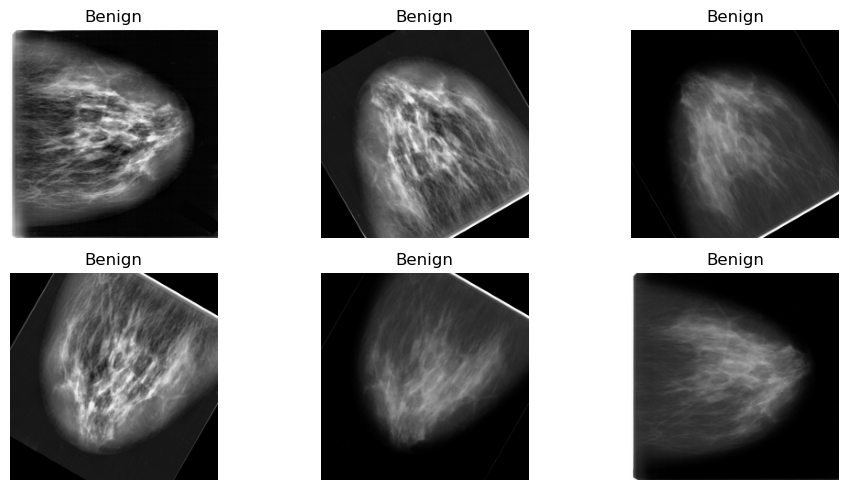

In [20]:
plot_sample_images()

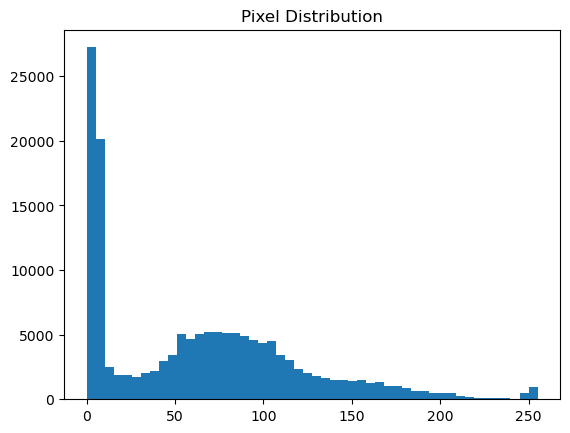

In [21]:
plot_pixel_histogram(preprocess_image(train_imgs[0]))

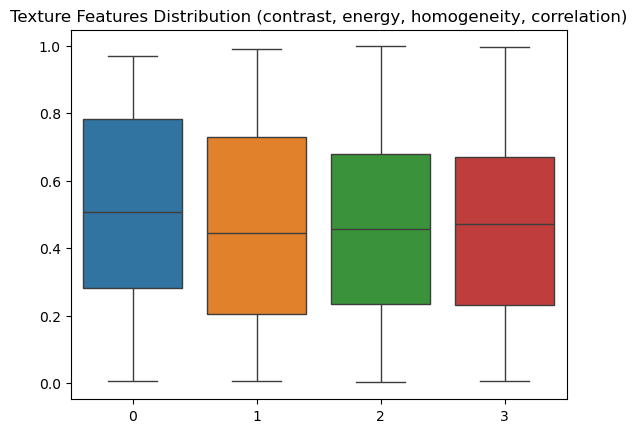

In [22]:
plot_texture_boxplot()

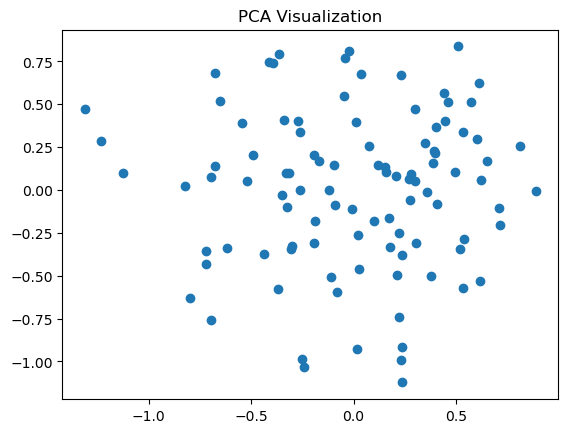

In [23]:
plot_pca()

### MODEL BUILDING

In [24]:
# EfficientNetB1 CLASSIFICATION MODEL
base_model = EfficientNetB1(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(128, activation='relu')(x)
x      = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model  = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 6,739,336 (25.71 MB)

 Trainable params: 6,677,281 (25.47 MB)

 Non-trainable params: 62,055 (242.41 KB)

In [25]:
# DATA GENERATORS
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
eval_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path, target_size=(224, 224), batch_size=16, class_mode='binary'
)
valid_data = eval_gen.flow_from_directory(
    valid_path, target_size=(224, 224), batch_size=16, class_mode='binary', shuffle=False
)
print("Class mapping:", train_data.class_indices)

Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Class mapping: {'Benign': 0, 'Malignant': 1}


In [26]:
# TRAINING WITH CALLBACKS (faster convergence)
callbacks = [
    EarlyStopping(monitor='val_auc', patience=4, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 486s 3s/step - accuracy: 0.6948 - auc: 0.7545 - loss: 0.5698 - val_accuracy: 0.6000 - val_auc: 0.5672 - val_loss: 0.6719 - learning_rate: 1.0000e-04
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 398s 3s/step - accuracy: 0.8748 - auc: 0.9436 - loss: 0.3045 - val_accuracy: 0.5133 - val_auc: 0.5465 - val_loss: 0.7280 - learning_rate: 1.0000e-04
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9114 - auc: 0.9687 - loss: 0.2269
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
132/132 ━━━━━━━━━━━━━━━━━━━━ 383s 3s/step - accuracy: 0.9157 - auc: 0.9700 - loss: 0.2175 - val_accuracy: 0.4333 - val_auc: 0.7170 - val_loss: 0.8213 - learning_rate: 1.0000e-04
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 912s 7s/step - accuracy: 0.9390 - auc: 0.9837 - loss: 0.1604 - val_accuracy: 0.6178 - val_auc: 0.7988 - val_loss: 0.6925 - learning_rate: 5.0000e-05
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9547 - auc: 0.9

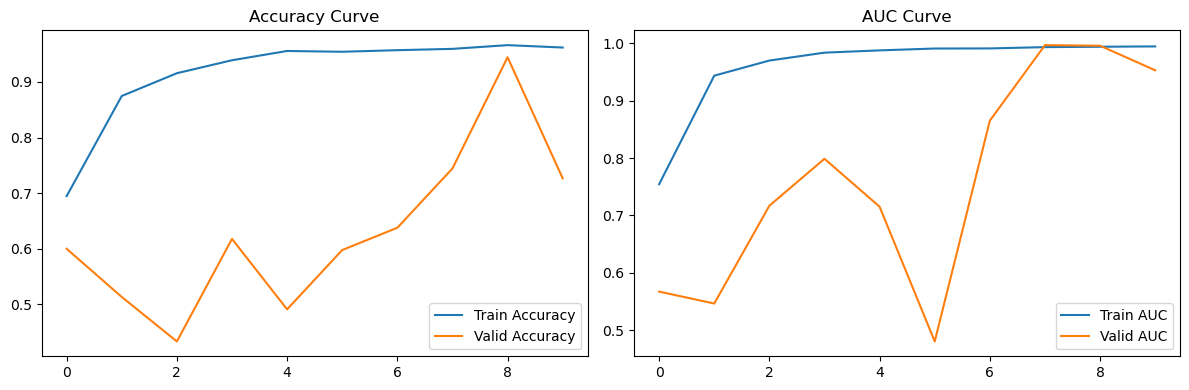

In [27]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Valid Accuracy')
plt.title("Accuracy Curve"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'],     label='Train AUC')
plt.plot(history.history['val_auc'], label='Valid AUC')
plt.title("AUC Curve"); plt.legend()
plt.tight_layout(); plt.show()

In [28]:
test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory(
    test_path, target_size=(224, 224), batch_size=16, class_mode='binary', shuffle=False
)

preds  = model.predict(test_data).ravel()
y_true = test_data.classes
y_pred = (preds > THRESHOLD).astype(int)

test_acc = accuracy_score(y_true, y_pred)
test_auc = roc_auc_score(y_true, preds)
pr_auc   = average_precision_score(y_true, preds)

print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"Test PR-AUC   : {pr_auc:.4f}")
print("\nDetailed Report:\n", classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))

Found 450 images belonging to 2 classes.
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 726ms/step

Test Accuracy : 0.8689
Test ROC-AUC  : 0.9942
Test PR-AUC   : 0.9961

Detailed Report:
               precision    recall  f1-score   support

      Benign       0.75      1.00      0.86       180
   Malignant       1.00      0.78      0.88       270

    accuracy                           0.87       450
   macro avg       0.88      0.89      0.87       450
weighted avg       0.90      0.87      0.87       450



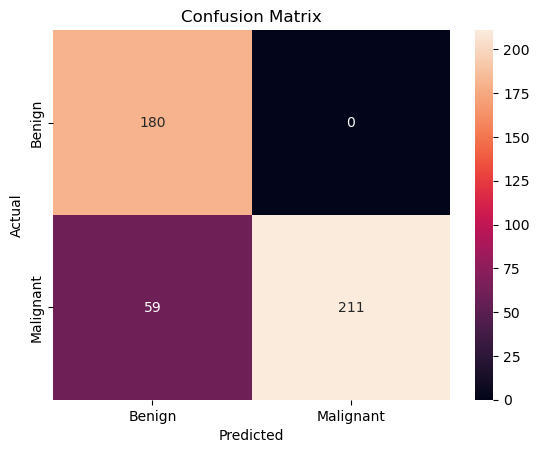

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title("Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

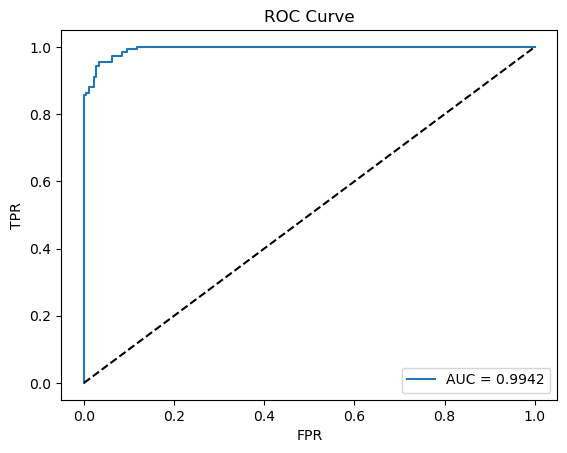

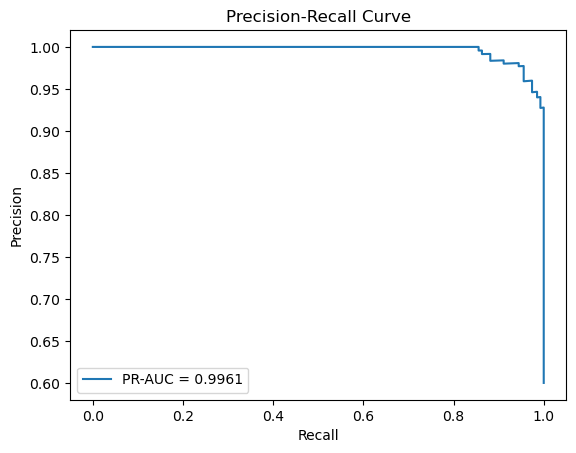

In [30]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_true, preds)
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, preds)
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.title("Precision-Recall Curve"); plt.xlabel("Recall"); plt.ylabel("Precision")
plt.legend(); plt.show()

In [31]:
# RECOMMENDATION ENGINE
def recommendation(pred, tumor_size):
    if pred < THRESHOLD:
        return {
            "Type":           "Benign",
            "Stage":          "Non-invasive",
            "Recommendation": "Regular follow-up (6–12 months)",
            "Treatment":      "Observation / Lumpectomy if needed",
            "Medicine":       "No cancer drugs required"
        }
    if tumor_size < 2:
        return {"Type": "Malignant", "Stage": "Stage 0",
                "Treatment": "Lumpectomy", "Medicine": "Tamoxifen"}
    elif tumor_size <= 2:
        return {"Type": "Malignant", "Stage": "Stage 1",
                "Treatment": "Lumpectomy + Radiation", "Medicine": "Tamoxifen / Anastrozole"}
    elif tumor_size <= 5:
        return {"Type": "Malignant", "Stage": "Stage 2",
                "Treatment": "Surgery", "Medicine": "Doxorubicin + Cyclophosphamide"}
    elif tumor_size > 5:
        return {"Type": "Malignant", "Stage": "Stage 3",
                "Treatment": "Chemotherapy", "Medicine": "Paclitaxel + Trastuzumab"}
    else:
        return {"Type": "Malignant", "Stage": "Stage 4",
                "Treatment": "Systematic Chemotherapy", "Medicine": "Capecitabine / Pembrolizumab"}

In [32]:
# FILE UPLOAD & FULL INFERENCE WITH ALL PARAMETERS
def process_uploaded_file(uploader):
    if not uploader.value:
        print("❌ No file uploaded"); return None

    uploaded = uploader.value
    if isinstance(uploaded, dict):
        content = list(uploaded.values())[0]['content']
    elif isinstance(uploaded, tuple):
        file_info = uploaded[0]
        content   = file_info['content'] if isinstance(file_info, dict) else file_info
    else:
        print("❌ Unsupported uploader format"); return None

    np_arr  = np.frombuffer(content, np.uint8)
    img     = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
    if img is None:
        print("❌ Error decoding image"); return None

    img     = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_norm = img_rgb / 255.0
    return img_rgb, img_norm

In [33]:
# WIDGET UPLOAD & RUN
from IPython.display import display
from ipywidgets import FileUpload

uploader = FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

In [35]:
def run_full_inference(uploader):
    result = process_uploaded_file(uploader)
    if result is None:
        return

    img_rgb, img_norm = result

    # Show uploaded image
    plt.imshow(img_rgb)
    plt.title("Uploaded Image")
    plt.axis('off')
    plt.show()

    # Deep Learning Prediction
    input_img = np.expand_dims(img_norm, axis=0)
    pred = model.predict(input_img, verbose=0)[0][0]

    # Tumor Size Estimation
    tumor_size, _ = estimate_tumor_size(img_rgb)

    # Recommendation
    rec = recommendation(pred, tumor_size)

    # Display Recommendation Only
    print("\n" + "=" * 60)
    print("🩺 RECOMMENDATION")
    print("=" * 60)

    for k, v in rec.items():
        print(f"{k:20s}: {v}")

    print("=" * 60)

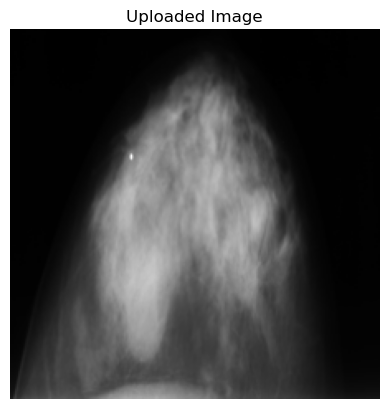


🩺 RECOMMENDATION
Type                : Malignant
Stage               : Stage 0
Treatment           : Lumpectomy
Medicine            : Tamoxifen


In [36]:
run_full_inference(uploader)